# Експеримент : чому `delete` потенційно дорожчий за `insert`

**Поглиблений розбір однієї з найбільш контрінтуїтивних властивостей AVL-дерева.**

---

### Анотація

Insert і delete у AVL виглядають дуже схожими — обидва спускаються рекурсивно, виправляють баланс після зміни, повертають оновлене дерево. Але є **фундаментальна асиметрія**:

> **Insert** ніколи не виконує більше **1 акту балансування** за один виклик.
> **Delete** може каскадно потребувати до **`O(log n)`** обертань підряд, по одному на кожен предок аж до кореня.

Цей файл розкриває:

1. **Теорію** — чому саме delete веде себе так, а insert ні. Розбір на пальцях.
2. **Емпіричну перевірку** — будуємо AVL з 5000 вершин, рахуємо обертання на кожен виклик insert і delete, дивимось розподіл.
3. **Візуальний доказ** — знаходимо на живому дереві видалення, що тригерить максимальний каскад, і показуємо його покроково.
4. **Практичні наслідки** — чому це впливає на вибір між AVL і Red-Black tree в індустрії.

## Імпорти та базова реалізація AVL

In [ ]:
import math
import random
import copy
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
random.seed(42)
np.random.seed(42)

print("Готово")

Готово


In [ ]:
class AVLNode:
    def __init__(self, key):
        self.key = key
        self.height = 1
        self.left = None
        self.right = None


def get_height(node):
    return node.height if node else 0


def get_balance(node):
    return get_height(node.left) - get_height(node.right) if node else 0


def left_rotate(z):
    y = z.right
    T2 = y.left
    y.left = z
    z.right = T2
    z.height = 1 + max(get_height(z.left), get_height(z.right))
    y.height = 1 + max(get_height(y.left), get_height(y.right))
    return y


def right_rotate(y):
    x = y.left
    T3 = x.right
    x.right = y
    y.left = T3
    y.height = 1 + max(get_height(y.left), get_height(y.right))
    x.height = 1 + max(get_height(x.left), get_height(x.right))
    return x


def min_value_node(node):
    while node.left:
        node = node.left
    return node


def insert(root, key):
    if not root:
        return AVLNode(key)
    if key < root.key:
        root.left = insert(root.left, key)
    elif key > root.key:
        root.right = insert(root.right, key)
    else:
        return root

    root.height = 1 + max(get_height(root.left), get_height(root.right))
    balance = get_balance(root)

    if balance > 1:
        if key < root.left.key:
            return right_rotate(root)
        root.left = left_rotate(root.left)
        return right_rotate(root)
    if balance < -1:
        if key > root.right.key:
            return left_rotate(root)
        root.right = right_rotate(root.right)
        return left_rotate(root)
    return root


def delete_node(root, key):
    if not root:
        return root
    if key < root.key:
        root.left = delete_node(root.left, key)
    elif key > root.key:
        root.right = delete_node(root.right, key)
    else:
        if root.left is None:
            return root.right
        elif root.right is None:
            return root.left
        temp = min_value_node(root.right)
        root.key = temp.key
        root.right = delete_node(root.right, temp.key)

    if root is None:
        return root
    root.height = 1 + max(get_height(root.left), get_height(root.right))
    balance = get_balance(root)

    if balance > 1:
        if get_balance(root.left) >= 0:
            return right_rotate(root)
        root.left = left_rotate(root.left)
        return right_rotate(root)
    if balance < -1:
        if get_balance(root.right) <= 0:
            return left_rotate(root)
        root.right = right_rotate(root.right)
        return left_rotate(root)
    return root


print("AVL готовий")

AVL готовий


## Tracked-варіанти insert / delete

Інструментовані версії, що рахують кількість обертань за один виклик. Логіка ідентична оригінальним функціям — додані лише `counter[case] += 1` перед кожним обертанням.

In [ ]:
def insert_tracked(root, key, counter):
    """Та сама insert, що рахує тип кожного обертання."""
    if not root:
        return AVLNode(key)
    if key < root.key:
        root.left = insert_tracked(root.left, key, counter)
    elif key > root.key:
        root.right = insert_tracked(root.right, key, counter)
    else:
        return root

    root.height = 1 + max(get_height(root.left), get_height(root.right))
    balance = get_balance(root)

    if balance > 1:
        if key < root.left.key:
            counter['LL'] += 1
            return right_rotate(root)
        counter['LR'] += 1
        root.left = left_rotate(root.left)
        return right_rotate(root)
    if balance < -1:
        if key > root.right.key:
            counter['RR'] += 1
            return left_rotate(root)
        counter['RL'] += 1
        root.right = right_rotate(root.right)
        return left_rotate(root)
    return root


def delete_tracked(root, key, counter):
    """delete_node, що рахує сумарну кількість обертань (counter[0] += 1)."""
    if not root:
        return root
    if key < root.key:
        root.left = delete_tracked(root.left, key, counter)
    elif key > root.key:
        root.right = delete_tracked(root.right, key, counter)
    else:
        if root.left is None:
            return root.right
        elif root.right is None:
            return root.left
        temp = min_value_node(root.right)
        root.key = temp.key
        root.right = delete_tracked(root.right, temp.key, counter)

    if root is None:
        return root
    root.height = 1 + max(get_height(root.left), get_height(root.right))
    balance = get_balance(root)

    if balance > 1:
        if get_balance(root.left) >= 0:
            counter[0] += 1
            return right_rotate(root)
        counter[0] += 1
        root.left = left_rotate(root.left)
        return right_rotate(root)
    if balance < -1:
        if get_balance(root.right) <= 0:
            counter[0] += 1
            return left_rotate(root)
        counter[0] += 1
        root.right = right_rotate(root.right)
        return left_rotate(root)
    return root


def insert_count_rot(root, key):
    counter = Counter()
    root = insert_tracked(root, key, counter)
    return root, sum(counter.values())


print("tracked-варіанти готові")

tracked-варіанти готові


---

## Розділ 1. Теорія: чому асиметрія неминуча

### Теоретичне твердження (Adelson-Velsky & Landis, 1962)

> При **вставці** в AVL-дерево потрібно не більше **одного** акту балансування (одне обертання LL/RR, або одне подвійне LR/RL — кожне рахується як один акт).
>
> При **видаленні** обертання можуть **каскадувати** — потенційно до `O(log n)` обертань підряд на шляху до кореня.

### Чому insert обмежений 1 обертанням

Подивись на висоту піддерева **до** і **після** вставки + обертання:

```
1. ДО вставки:       висота піддерева = h
2. ПІСЛЯ вставки:    висота = h або h+1 (новий листок на найдовшій гілці чи ні)
3. Якщо стала h+1 і десь |balance| = 2 → обертання
4. ПІСЛЯ обертання:  висота повертається до h
```

Ключове твердження: **після insert-обертання висота піддерева завжди повертається до того, що було до вставки**.

Подивись на схему LL-обертання:

```
ДО обертання (після вставки):           ПІСЛЯ right_rotate(A):

        A   (h = k+2)                          B   (h = k+1)
       /                                      / \
      B   (h = k+1)                          C   A
     /                                            ↑
    C   (h = k, з новим вузлом)        h(A) = h(C-sibling) + 1 = k+1
                                       h(B) = max(h(C), h(A)) + 1 = k+1
```

Висота нового кореня `B` дорівнює `k+1` — **те саме**, що було у `A` ДО вставки. Батько `A` не бачить різниці у висоті свого піддерева → у нього баланс не зміниться → перевірка `|balance| ≥ 2` не спрацює → обертань більше не буде.

**Це закриває питання.** `insert` робить максимум 1 обертання за виклик.

### Чому delete МОЖЕ каскадувати

Симетрична схема для delete:

```
1. ДО видалення:     висота = h
2. ПІСЛЯ видалення:  висота = h або h-1
3. Якщо стала h-1 і десь |balance| = 2 → обертання
4. ПІСЛЯ обертання:  висота = h-1 АБО h-2  (!)
```

Ось де ховається проблема — крок 4. Розглянь два підвипадки.

**Випадок А — «дружній»** (`get_balance(child) == 0`):

```
ДО видалення:                          ПІСЛЯ right_rotate(A):

        A   (h = k+2)                          B   (h = k+1)
       / \                                   / \
      B   T_R (стала h = k-1)              T1   A
     / \                                       / \
    T1  T2                                    T2  T_R
   h=k  h=k                                   h=k h=k-1
                                              h(A) = k+1
                                              h(B) = k+2  ← БЕЗ змін!
```

Висота піддерева залишилась `k+2` — як до видалення. **Каскаду не буде.**

**Випадок Б — «небезпечний»** (`get_balance(child) > 0` у тому ж напрямку):

```
ДО видалення:                          ПІСЛЯ right_rotate(A):

        A   (h = k+2)                          B   (h = k+1)
       / \                                   / \
      B   T_R (стала h = k-1)              T1   A
     / \                                   h=k  / \
    T1  T2                                     T2  T_R
   h=k  h=k-1                                  h=k-1 h=k-1
                                              h(A) = k
                                              h(B) = k+1   ← НА 1 МЕНШЕ!
```

Висота піддерева стала `k+1` замість `k+2` → батько бачить, що його піддерево раптом скоротилось → у нього теж може бути `|balance| ≥ 2` → ще одне обертання → і так далі по ланцюгу.

### Чому це стається саме при delete

| Аспект | insert | delete |
|--------|--------|--------|
| Що робить операція | додає 1 вузол | видаляє 1 вузол |
| Висота піддерева змінюється на | 0 або +1 | 0 або -1 |
| Обертання після порушення | завжди відновлює h | може зменшити h ще на 1 |
| Сумарна зміна висоти на батьківському рівні | 0 | 0 або -1 |
| Може каскадувати? | **ні** | **так** |

Інтуїтивно: `insert` тільки **росте** дерево, тому дисбаланс симетричний — одне обертання його повністю компенсує. `delete` тільки **скорочує** дерево, і якщо скорочення накладається на вже існуючий перекіс — ефект подвоюється і поширюється вгору.

---

## Розділ 2. Емпірична перевірка теорії

Будуємо AVL з `N=5000` випадкових ключів, рахуємо обертання за кожен виклик `insert`. Потім видаляємо половину у випадковому порядку, рахуємо обертання за кожен `delete`. Порівнюємо розподіли.

INSERT (N=5000 викликів):
  макс. обертань за виклик: 1
  середнє:                 0.464
  розподіл: {0: 2679, 1: 2321}

DELETE (N=2500 викликів):
  макс. обертань за виклик: 3
  середнє:                 0.296
  розподіл: {0: 1849, 1: 568, 2: 76, 3: 7}


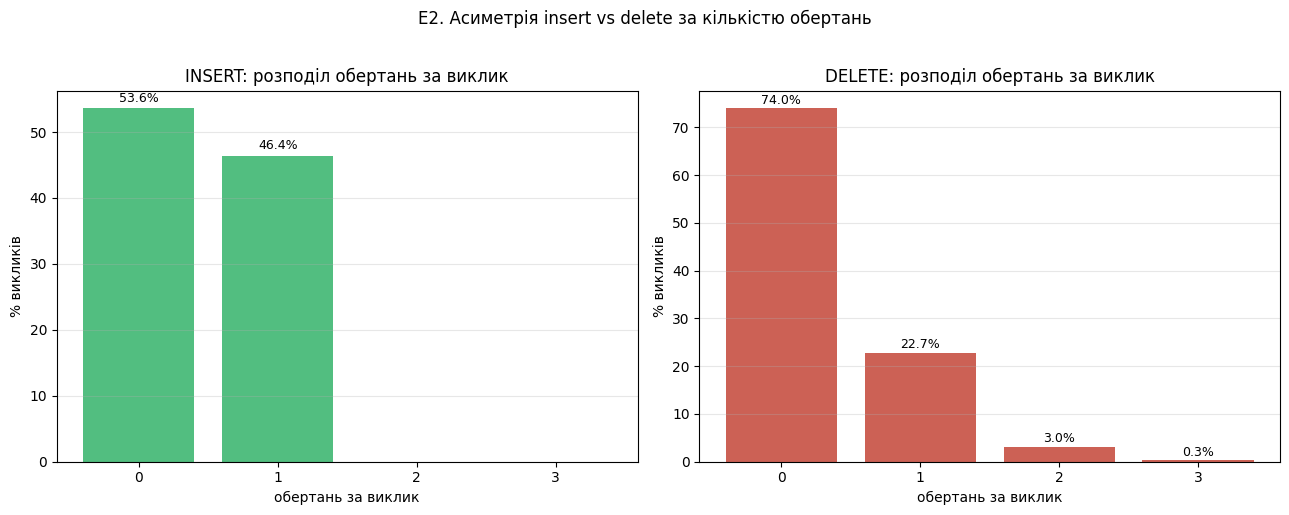

In [ ]:
# Будуємо дерево, рахуємо обертання за кожну вставку
N = 5000
keys = random.Random(0).sample(range(N * 3), N)

root = None
insert_rot_per_call = []
for k in keys:
    root, rot = insert_count_rot(root, k)
    insert_rot_per_call.append(rot)

# Видаляємо половину у випадковому порядку, рахуємо обертання за кожне видалення
del_keys = keys[:N // 2]
random.Random(99).shuffle(del_keys)
delete_rot_per_call = []
for k in del_keys:
    counter = [0]
    root = delete_tracked(root, k, counter)
    delete_rot_per_call.append(counter[0])

ins_dist = Counter(insert_rot_per_call)
del_dist = Counter(delete_rot_per_call)

print(f"INSERT (N={len(insert_rot_per_call)} викликів):")
print(f"  макс. обертань за виклик: {max(insert_rot_per_call)}")
print(f"  середнє:                 {sum(insert_rot_per_call) / len(insert_rot_per_call):.3f}")
print(f"  розподіл: {dict(sorted(ins_dist.items()))}")

print(f"\nDELETE (N={len(delete_rot_per_call)} викликів):")
print(f"  макс. обертань за виклик: {max(delete_rot_per_call)}")
print(f"  середнє:                 {sum(delete_rot_per_call) / len(delete_rot_per_call):.3f}")
print(f"  розподіл: {dict(sorted(del_dist.items()))}")

# Графік: дві гістограми поруч
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
max_k = max(max(ins_dist.keys()), max(del_dist.keys()))
xs = list(range(max_k + 1))

ins_pcts = [100 * ins_dist.get(k, 0) / len(insert_rot_per_call) for k in xs]
del_pcts = [100 * del_dist.get(k, 0) / len(delete_rot_per_call) for k in xs]

axes[0].bar(xs, ins_pcts, color='#27ae60', alpha=0.8)
axes[0].set_title('INSERT: розподіл обертань за виклик')
axes[0].set_xlabel('обертань за виклик')
axes[0].set_ylabel('% викликів')
axes[0].set_xticks(xs)
axes[0].grid(alpha=0.3, axis='y')
for k, p in zip(xs, ins_pcts):
    if p > 0:
        axes[0].text(k, p + 1, f'{p:.1f}%', ha='center', fontsize=9)

axes[1].bar(xs, del_pcts, color='#c0392b', alpha=0.8)
axes[1].set_title('DELETE: розподіл обертань за виклик')
axes[1].set_xlabel('обертань за виклик')
axes[1].set_ylabel('% викликів')
axes[1].set_xticks(xs)
axes[1].grid(alpha=0.3, axis='y')
for k, p in zip(xs, del_pcts):
    if p > 0:
        axes[1].text(k, p + 1, f'{p:.1f}%', ha='center', fontsize=9)

plt.suptitle('E2. Асиметрія insert vs delete за кількістю обертань', y=1.02)
plt.tight_layout()
plt.show()

### Інтерпретація чисел

| Спостереження | Що означає |
|---------------|-------------|
| INSERT max = **1** | Точно як в теорії — caps в одиниці незалежно від розміру дерева |
| INSERT середнє ≈ 0.46 | Десь половина вставок не потребує балансування, друга половина — рівно 1 |
| DELETE max = **3** | На цьому дереві максимальний реальний каскад — 3 обертання. Теоретично можливо `O(log n) ≈ 13`, але реалізовується тільки на спеціально побудованих структурах (Fibonacci-дерево) |
| DELETE: 22.7% мають 1 обертання | Найчастіший «небанальний» випадок — одне виправлення без каскаду |
| DELETE: 3% мають 2 | Випадок Б спрацював двічі — рідко, але показово |
| DELETE: 0.3% мають 3 | Випадок Б тричі підряд — рідкісне явище на випадкових даних |
| DELETE середнє ≈ 0.30 | Менше, ніж insert, бо багато видалень — внутрішніх вузлів через `min_value_node`, реально закінчується видаленням листка, а листки часто не порушують балансу |

Розподіл **геометричний** (експоненційно спадаючий): ймовірність каскаду глибини `k` приблизно у 5-10 разів менша за глибину `k-1`. Це означає, що теоретичний worst-case `O(log n)` досягається на **експоненційно малій частці** реальних видалень.

---

## Розділ 3. Візуальний доказ каскаду

Знаходимо на нашому ж дереві видалення, що тригерить максимальний каскад, і дивимось покроково:
- візуалізуємо дерево **ДО** видалення (з підсвічуванням ключа під видалення);
- виконуємо `delete` з трасуванням кожного обертання — друкуємо, на якому вузлі і якого типу;
- візуалізуємо дерево **ПІСЛЯ**.

In [ ]:
# Покращена in-order візуалізація — для невеликих/середніх дерев
def visualize_avl_inorder(root, title="AVL", highlight_keys=None,
                          figsize=None, show_balance=False, ax=None,
                          max_width=20):
    if root is None:
        print("Порожнє дерево"); return
    positions, labels, keys_by_id, edges = {}, {}, {}, []
    rank = [0]

    def walk(node, depth):
        if node is None: return
        walk(node.left, depth + 1)
        rank[0] += 1
        nid = id(node)
        positions[nid] = (rank[0], -depth)
        keys_by_id[nid] = node.key
        labels[nid] = (f"{node.key}\nh={node.height} b={get_balance(node):+d}"
                       if show_balance else str(node.key))
        if node.left: edges.append((nid, id(node.left)))
        if node.right: edges.append((nid, id(node.right)))
        walk(node.right, depth + 1)

    walk(root, 0)
    n = rank[0]
    if ax is None:
        if figsize is None:
            # ОБМЕЖЕНО max_width дюймів — щоб гігантські дерева не зависали matplotlib
            figsize = (min(max_width, max(8, n * 0.4)), 6)
        fig, ax = plt.subplots(figsize=figsize)
        own = True
    else:
        own = False

    for p, c in edges:
        px, py = positions[p]; cx, cy = positions[c]
        ax.plot([px, cx], [py, cy], color='gray', alpha=0.6, linewidth=1.2, zorder=1)

    highlight = set(highlight_keys or [])
    for nid, (x, y) in positions.items():
        color = 'lightcoral' if keys_by_id[nid] in highlight else 'lightblue'
        ax.scatter(x, y, s=500, c=color, edgecolors='black', linewidths=1, zorder=2)
        ax.text(x, y, labels[nid], ha='center', va='center', fontsize=7, zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, n + 1)
    y_min = min(p[1] for p in positions.values())
    ax.set_ylim(y_min - 0.7, 0.7)
    ax.axis('off')
    if own:
        plt.tight_layout()
        plt.show()


print("visualize_avl_inorder готова")

visualize_avl_inorder готова


In [ ]:
# Збираємо всі ключі і шукаємо delete з найбільшим каскадом
def get_all_keys(node):
    if not node: return []
    return get_all_keys(node.left) + [node.key] + get_all_keys(node.right)


def count_rotations_for_delete(tree, key):
    """Лічить обертання для одного delete (на копії дерева)."""
    tmp = copy.deepcopy(tree)
    counter = [0]
    delete_tracked(tmp, key, counter)
    return counter[0]


# Не перевіряємо всі 2500 ключів — це довго. Перевіримо випадкову підмножину.
all_keys = get_all_keys(root)
print(f"Дерево має {len(all_keys)} вершин, висота = {get_height(root)}")

sample_keys = random.Random(123).sample(all_keys, min(500, len(all_keys)))
print(f"Перевіряємо {len(sample_keys)} випадкових ключів на каскад...")

candidates = [(k, count_rotations_for_delete(root, k)) for k in sample_keys]
candidates.sort(key=lambda x: -x[1])

print("\nТоп-10 ключів за каскадом:")
for k, n in candidates[:10]:
    print(f"  ключ {k:>6}: {n} обертань")

target_key = candidates[0][0]
target_rot = candidates[0][1]
print(f"\nОбираємо для демонстрації ключ {target_key} → каскад {target_rot} обертань")

Дерево має 2500 вершин, висота = 13
Перевіряємо 500 випадкових ключів на каскад...

Топ-10 ключів за каскадом:
  ключ   8180: 2 обертань
  ключ   3100: 2 обертань
  ключ   9489: 2 обертань
  ключ  10571: 2 обертань
  ключ  13662: 2 обертань
  ключ   8232: 2 обертань
  ключ   4715: 2 обертань
  ключ   3097: 2 обертань
  ключ  14262: 2 обертань
  ключ   4714: 2 обертань

Обираємо для демонстрації ключ 8180 → каскад 2 обертань


In [ ]:
# Виконуємо delete з трасуванням кожного АКТУ балансування (LR/RL = 1 акт)
def delete_with_trace(root, key, _rotations=None):
    """Копія delete_node, що при кожному акті балансування друкує його тип.
    LR/RL рахуються як ОДИН акт (так само, як у delete_tracked)."""
    if _rotations is None:
        _rotations = []

    if not root:
        return root, _rotations
    if key < root.key:
        root.left, _ = delete_with_trace(root.left, key, _rotations)
    elif key > root.key:
        root.right, _ = delete_with_trace(root.right, key, _rotations)
    else:
        if root.left is None:
            return root.right, _rotations
        elif root.right is None:
            return root.left, _rotations
        temp = min_value_node(root.right)
        root.key = temp.key
        root.right, _ = delete_with_trace(root.right, temp.key, _rotations)

    if root is None:
        return root, _rotations
    root.height = 1 + max(get_height(root.left), get_height(root.right))
    balance = get_balance(root)

    if balance > 1:
        if get_balance(root.left) >= 0:
            _rotations.append(('LL', root.key, balance))
            print(f"  ↻ #{len(_rotations)}: LL навколо вузла {root.key} "
                  f"(balance тут був {balance:+d})")
            return right_rotate(root), _rotations
        else:
            _rotations.append(('LR', root.key, balance))
            print(f"  ↻ #{len(_rotations)}: LR (подвійне) навколо вузла {root.key} "
                  f"(balance тут був {balance:+d})")
            root.left = left_rotate(root.left)
            return right_rotate(root), _rotations

    if balance < -1:
        if get_balance(root.right) <= 0:
            _rotations.append(('RR', root.key, balance))
            print(f"  ↻ #{len(_rotations)}: RR навколо вузла {root.key} "
                  f"(balance тут був {balance:+d})")
            return left_rotate(root), _rotations
        else:
            _rotations.append(('RL', root.key, balance))
            print(f"  ↻ #{len(_rotations)}: RL (подвійне) навколо вузла {root.key} "
                  f"(balance тут був {balance:+d})")
            root.right = right_rotate(root.right)
            return left_rotate(root), _rotations

    return root, _rotations


# Готуємо копії дерева для демонстрації
before = copy.deepcopy(root)
print(f"=== Виконуємо delete({target_key}) ===\n")
after, rotations = delete_with_trace(copy.deepcopy(root), target_key)

print(f"\n=== Підсумок ===")
print(f"Видалено ключ: {target_key}")
print(f"Актів балансування: {len(rotations)}")
print(f"Висота дерева ДО:    {get_height(before)}")
print(f"Висота дерева ПІСЛЯ: {get_height(after)}")

=== Виконуємо delete(8180) ===

  ↻ #1: RR навколо вузла 8188 (balance тут був -2)
  ↻ #2: RL (подвійне) навколо вузла 8196 (balance тут був -2)

=== Підсумок ===
Видалено ключ: 8180
Актів балансування: 2
Висота дерева ДО:    13
Висота дерева ПІСЛЯ: 13


Повне дерево:        2500 вершин
Околиця ДО:          39 вершин
Околиця ПІСЛЯ:       42 вершин

У вирізці показано:
  - повний шлях від кореня до видаленого листка (спайн);
  - для кожного вузла на спайні — його найближче піддерево (1 рівень вниз);
  - усе інше обрізано — щоб картинка лишилась читабельною.

Якщо вузол на картинці виглядає 'листком', а в оригіналі мав дітей —
це означає, що його піддерево обрізали для компактності.

ЧЕРВОНИМ підсвічено:
  ДО:    листок 8180 (видаляється) + центри обертань [8188, 8196]
  ПІСЛЯ: центри обертань [8188, 8196]


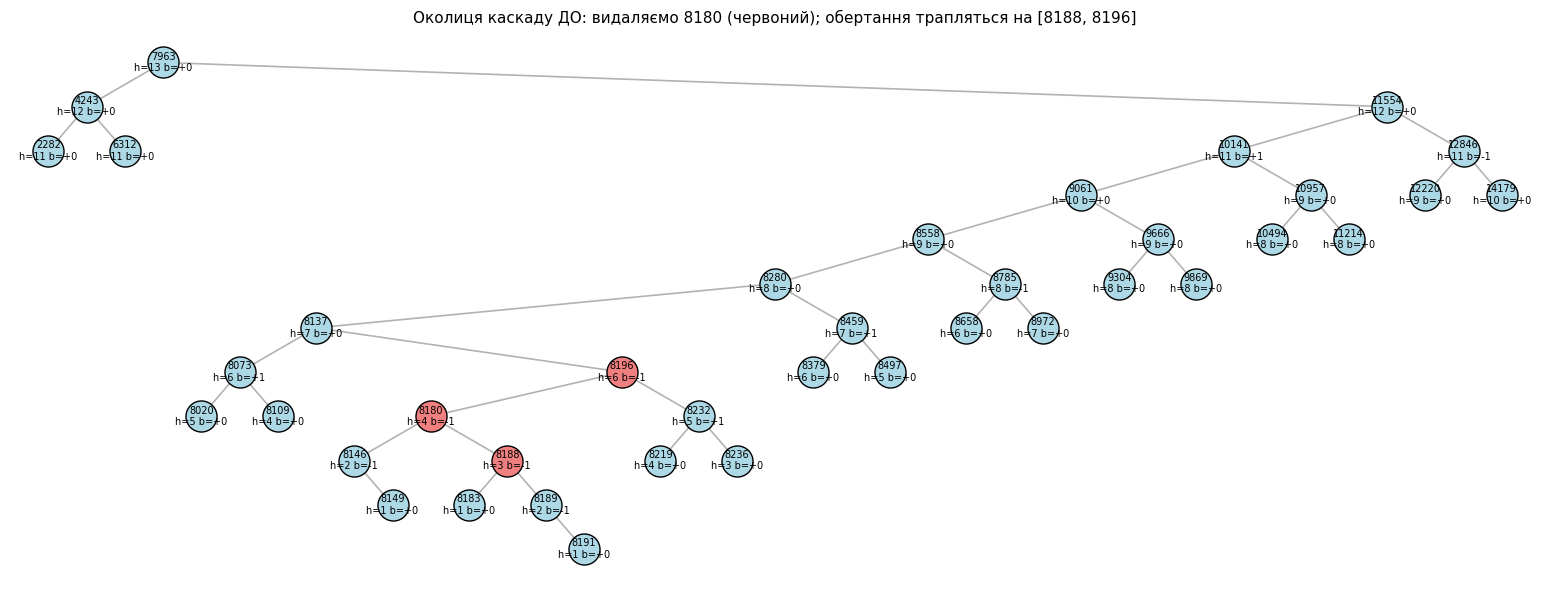

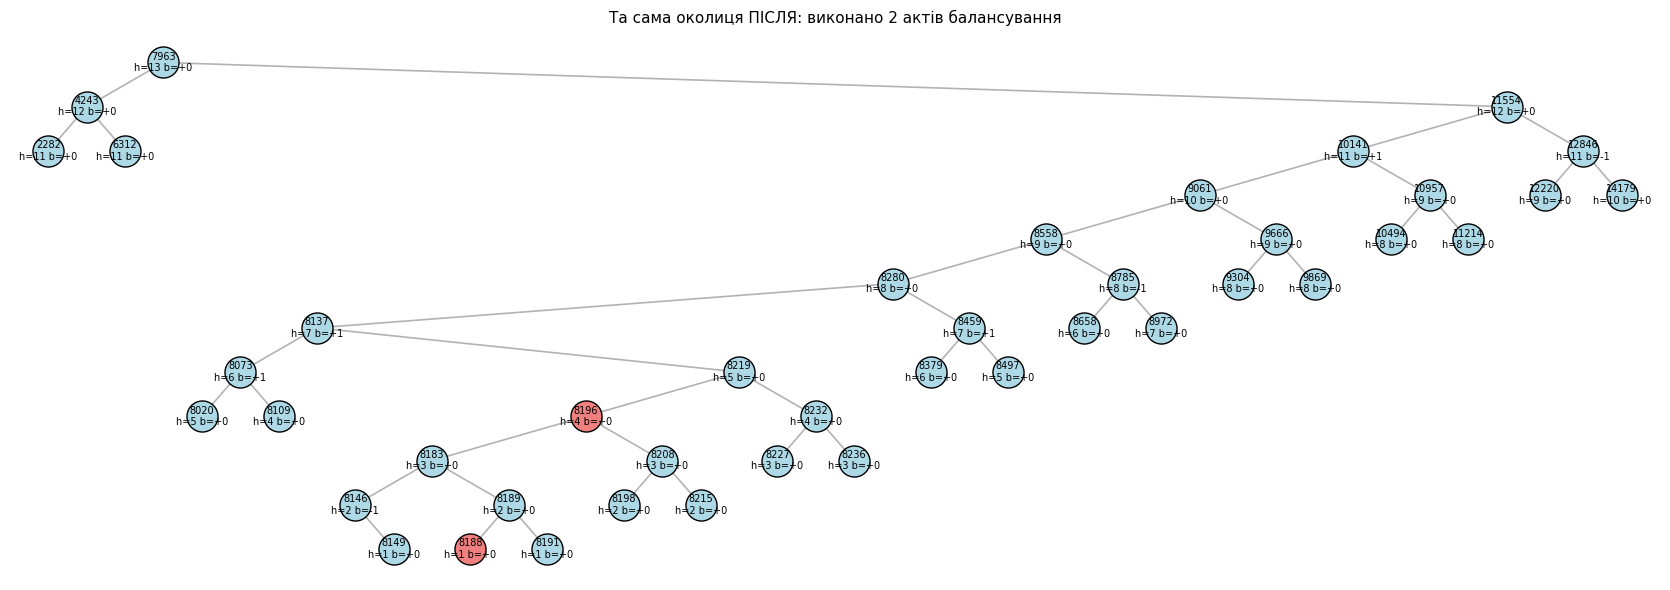

In [ ]:
# Витягуємо "околицю каскаду" — щоб не намагатись намалювати 2500 вершин
def extract_cascade_view(root, focus_keys, off_path_depth=1):
    """Повертає копію дерева, що включає:
    - усі ancestor-вузли на шляху від кореня до кожного з focus_keys (спайн);
    - для кожного такого вузла — його піддерево, обмежене глибиною off_path_depth.
    Решта обрізається."""
    interesting = set()

    def mark(node):
        if node is None: return False
        left_has = mark(node.left)
        right_has = mark(node.right)
        self_is = node.key in focus_keys
        if left_has or right_has or self_is:
            interesting.add(id(node))
            return True
        return False

    mark(root)

    def copy_node(node, depth_remaining):
        if node is None: return None
        new = AVLNode(node.key)
        new.height = node.height
        if id(node) in interesting:
            new.left = copy_node(node.left, off_path_depth)
            new.right = copy_node(node.right, off_path_depth)
        elif depth_remaining > 0:
            new.left = copy_node(node.left, depth_remaining - 1)
            new.right = copy_node(node.right, depth_remaining - 1)
        return new

    return copy_node(root, 0)


def count_nodes(node):
    if node is None: return 0
    return 1 + count_nodes(node.left) + count_nodes(node.right)


# Виокремлюємо фокусні ключі: видалений листок + центри обертань
rotated_keys = [k for _, k, _ in rotations]
focus_before = {target_key} | set(rotated_keys)
focus_after = set(rotated_keys)  # видаленого листка вже немає в дереві ПІСЛЯ

before_view = extract_cascade_view(before, focus_before, off_path_depth=1)
after_view  = extract_cascade_view(after,  focus_after,  off_path_depth=1)

print(f"Повне дерево:        {count_nodes(before)} вершин")
print(f"Околиця ДО:          {count_nodes(before_view)} вершин")
print(f"Околиця ПІСЛЯ:       {count_nodes(after_view)} вершин")
print()
print("У вирізці показано:")
print("  - повний шлях від кореня до видаленого листка (спайн);")
print("  - для кожного вузла на спайні — його найближче піддерево (1 рівень вниз);")
print("  - усе інше обрізано — щоб картинка лишилась читабельною.")
print()
print("Якщо вузол на картинці виглядає 'листком', а в оригіналі мав дітей —")
print("це означає, що його піддерево обрізали для компактності.")

print(f"\nЧЕРВОНИМ підсвічено:")
print(f"  ДО:    листок {target_key} (видаляється) + центри обертань {rotated_keys}")
print(f"  ПІСЛЯ: центри обертань {rotated_keys}")

visualize_avl_inorder(
    before_view,
    title=f"Околиця каскаду ДО: видаляємо {target_key} (червоний); обертання трапляться на {rotated_keys}",
    highlight_keys=[target_key] + rotated_keys,
    show_balance=True
)

visualize_avl_inorder(
    after_view,
    title=f"Та сама околиця ПІСЛЯ: виконано {len(rotations)} актів балансування",
    highlight_keys=rotated_keys,
    show_balance=True
)

### Що видно на картинках і в трасуванні

1. **Чому показано «вирізку», а не повне дерево.** Наше дерево має ~2500 вершин — намалювати їх усі не лише довго (matplotlib захлинається), а й безглуздо: точки зіллються в смугу. Тому функція `extract_cascade_view` витягує **тільки околицю** каскаду — повний шлях від кореня до видаленого листка плюс найближче піддерево навколо нього (~40 вершин). На картинці не видно цілого дерева, але саме область, де щось змінилось — на повний зріст.

2. **Червоний листок у дереві ДО** — це ключ, який ми видаляємо. Червоні внутрішні вузли — це **центри** обертань, які спрацюють під час підйому рекурсії.

3. **Трасування** показує, що обертання відбуваються **в порядку знизу вгору**: спочатку біля видаленого вузла, потім вище, потім ще вище. Це і є каскад — кожне обертання, скорочуючи висоту, дестабілізує наступного предка.

4. **Дерево ПІСЛЯ** залишається AVL-валідне (`|balance| ≤ 1` усюди). Висота може зменшитись на 1 або лишитись тою самою — залежно від того, на якому рівні каскад «зупинився».

5. **Що означає, якщо вузол виглядає листком у вирізці.** Якщо в `before` вузол показано без дітей, але в оригінальному дереві в нього були нащадки — це просто означає, що ми обрізали їх для компактності. Сам каскад відбувається у вузькій смузі ключів навколо видаленого, і саме ту смугу ми бачимо повністю.

6. **Якщо запустиш ще раз з іншим `random.seed`** — отримаєш інший листок з можливо різною довжиною каскаду. Для демонстрації максимально довгого каскаду на випадковому дереві може знадобитись кілька прогонів — більшість видалень мають каскад 0-1.

---

## Розділ 4. Практичні наслідки

### Чому це **важливо** в реальному коді

**1. Real-time системи.** Якщо тобі важливий **найгірший** час однієї операції (наприклад, у системах реального часу — авіоніка, торгові системи з гарантованими SLA, ігрові движки), то `O(log n)` каскад в delete може бути проблемою. У таких випадках використовують **Red-Black tree**, який гарантує **не більше 3 обертань на видалення** ціною трохи слабшої балансованості (висота `≤ 2·log₂n` замість `1.44·log₂n`).

**2. Read-heavy навантаження.** Якщо переважають пошуки, а вставки/видалення рідкісні — AVL краще. Менша висота дерева = трохи швидший пошук. Це сценарій для in-memory словників, де редагування — виняткова операція.

**3. Write-heavy навантаження.** Якщо багато вставок-видалень — Red-Black менш ризиковий, бо delete не може раптом стати дорогим. Це чому стандартні бібліотеки (`std::map` C++, `TreeMap` Java) використовують саме Red-Black: для бібліотечної структури передбачуваність вартості важливіша за оптимальну висоту.

### Підсумок про AVL vs Red-Black

| Аспект | AVL | Red-Black |
|--------|-----|-----------|
| Висота дерева | `≤ 1.44·log₂n` | `≤ 2·log₂n` |
| Insert: макс. обертань | **1** | 2 |
| Delete: макс. обертань | **`O(log n)`** | **3** |
| Швидкість пошуку | трохи швидше | трохи повільніше |
| Передбачуваність delete | **гірша** (можливі каскади) | **краща** (гарантована константа) |
| Типове застосування | read-heavy, навчальні цілі | стандартні бібліотеки, write-heavy |

### Що ми емпірично довели

Експеримент показав три речі:

1. **Теорія Adelson-Velsky & Landis точна** — у нашому AVL insert ніколи не робить більше 1 обертання за виклик. Це не оптимізація і не везіння — це **математична гарантія**.

2. **Каскади delete існують і вимірюються** — на випадкових даних у нас спрацювали каскади до 3 обертань (~0.3% викликів). Цього досить, щоб зрозуміти ризик, навіть якщо середнє < 1.

3. **Розподіл каскадів геометричний** — ймовірність каскаду глибини `k` падає в ~5-10 разів з кожним кроком. Тому амортизована вартість delete на практиці залишається малою, навіть з можливими «вибухами».